Muc chiet khau de xuat: 23.52 %


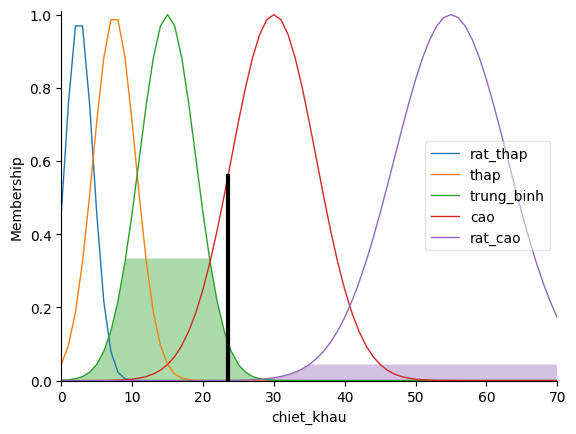

In [4]:
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau')
ap_luc_canh_tranh = ctrl.Antecedent(np.arange(0, 101, 1), 'ap_luc_canh_tranh')
uy_tin = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'uy_tin')
bien_loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'bien_loi_nhuan')
mua_vu = ctrl.Antecedent(np.arange(0, 101, 1), 'mua_vu')

chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')

nhu_cau['thap'] = fuzzy.trapmf(nhu_cau.universe, [0, 0, 20, 40])
nhu_cau['trung_binh'] = fuzzy.trapmf(nhu_cau.universe, [30, 50, 60, 80])
nhu_cau['cao'] = fuzzy.trapmf(nhu_cau.universe, [70, 85, 100, 100])

ap_luc_canh_tranh['thap'] = fuzzy.gaussmf(ap_luc_canh_tranh.universe, 0, 20)
ap_luc_canh_tranh['trung_binh'] = fuzzy.gaussmf(ap_luc_canh_tranh.universe, 50, 15)
ap_luc_canh_tranh['cao'] = fuzzy.gaussmf(ap_luc_canh_tranh.universe, 100, 20)

uy_tin['thap'] = fuzzy.trimf(uy_tin.universe, [0, 0, 3.8])
uy_tin['trung_binh'] = fuzzy.trimf(uy_tin.universe, [3.5, 4.2, 4.6])
uy_tin['cao'] = fuzzy.trimf(uy_tin.universe, [4.4, 5, 5])

bien_loi_nhuan['thap'] = fuzzy.trapmf(bien_loi_nhuan.universe, [0, 0, 20, 45])
bien_loi_nhuan['trung_binh'] = fuzzy.trapmf(bien_loi_nhuan.universe, [35, 50, 65, 80])
bien_loi_nhuan['cao'] = fuzzy.trapmf(bien_loi_nhuan.universe, [75, 90, 100, 100])

mua_vu['khong_co'] = fuzzy.trimf(mua_vu.universe, [0, 0, 25])
mua_vu['trung_binh'] = fuzzy.trimf(mua_vu.universe, [20, 50, 80])
mua_vu['cao'] = fuzzy.trimf(mua_vu.universe, [70, 100, 100])

chiet_khau['rat_thap'] = fuzzy.gaussmf(chiet_khau.universe, 2.5, 2)
chiet_khau['thap'] = fuzzy.gaussmf(chiet_khau.universe, 7.5, 3)
chiet_khau['trung_binh'] = fuzzy.gaussmf(chiet_khau.universe, 15, 4)
chiet_khau['cao'] = fuzzy.gaussmf(chiet_khau.universe, 30, 6)
chiet_khau['rat_cao'] = fuzzy.gaussmf(chiet_khau.universe, 55, 8)

l1 = ctrl.Rule(nhu_cau['cao'] & ap_luc_canh_tranh['thap'] & bien_loi_nhuan['thap'], chiet_khau['rat_thap'])
l2 = ctrl.Rule(nhu_cau['thap'] & ap_luc_canh_tranh['cao'] & bien_loi_nhuan['cao'], chiet_khau['cao'])
l3 = ctrl.Rule(uy_tin['cao'] & bien_loi_nhuan['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh'])
l4 = ctrl.Rule(ap_luc_canh_tranh['cao'] & mua_vu['cao'] & bien_loi_nhuan['cao'], chiet_khau['rat_cao'])
l5 = ctrl.Rule(uy_tin['thap'] & nhu_cau['trung_binh'] & bien_loi_nhuan['thap'], chiet_khau['trung_binh'])
l6 = ctrl.Rule(nhu_cau['cao'] & mua_vu['khong_co'] & ap_luc_canh_tranh['thap'], chiet_khau['rat_thap'])
l7 = ctrl.Rule(bien_loi_nhuan['cao'] & ap_luc_canh_tranh['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh'])

he_thong = ctrl.ControlSystem([l1, l2, l3, l4, l5, l6, l7])
mo_phong = ctrl.ControlSystemSimulation(he_thong)

mo_phong.input['nhu_cau'] = 90
mo_phong.input['ap_luc_canh_tranh'] = 50
mo_phong.input['uy_tin'] = 4.2
mo_phong.input['bien_loi_nhuan'] = 80
mo_phong.input['mua_vu'] = 90

mo_phong.compute()

print(f'Muc chiet khau de xuat: {mo_phong.output["chiet_khau"]:.2f} %')

chiet_khau.view(sim=mo_phong)
plt.show()
